In [ ]:
## Load and Compare Phenotype Data from HDF5 and Text Files

This section loads phenotype data for two specific traits (`DTA` and `DTT`) from two different sources:
1.  A preprocessed HDF5 file (`maize1404_preprocessed_newtry.h5`).
2.  A raw text file (`Agronomic_23Traits.txt`).

It then generates a scatter plot to visually compare the relationship between the two selected phenotypes (`DTA` vs. `DTT`). Data points from the HDF5 file are plotted in blue, while data points from the text file are plotted in red with 'x' markers. The code includes error handling for cases where files are not found or the specified phenotypes do not exist in the files.

INFO:TestPhenotypeNotebook:Loading data from HDF5 file: /media/marxin/softs/workspace/Whisper_of_DNA_pl/output/maize1404_test_memory/maize1404_preprocessed_newtry.h5
INFO:TestPhenotypeNotebook:Successfully loaded 1404 samples and 23 phenotypes from HDF5.
INFO:TestPhenotypeNotebook:Available phenotypes in HDF5: ['ATI', 'CW', 'DTA', 'DTS', 'DTT', 'ED', 'EH', 'EL', 'ELL', 'ELW', 'ERN', 'EW', 'KNPE', 'KNPR', 'KWPE', 'LBT', 'LNAE', 'LNBE', 'PH', 'SAI', 'STI', 'TBN', 'TL']
INFO:TestPhenotypeNotebook:Found 'DTT' at index 4 in HDF5.
INFO:TestPhenotypeNotebook:Found 'DTS' at index 3 in HDF5.
INFO:TestPhenotypeNotebook:Extracted data for 'DTT' and 'DTS' from HDF5. Shape: (1404, 2)



Loading data from text file: /media/marxin/softs/workspace/Whisper_of_DNA_pl/data/maize1404_genotype/Agronomic_23Traits.txt
Successfully loaded text file. Shape: (1404, 23)
Found 'DTT' and 'DTS' columns in the text file.
Extracted data for 'DTT' and 'DTS' from text file. Initial shape: (1404, 2)
Removed 2 rows containing NaN values. Final shape: (1402, 2)

Generating scatter plot...
Plotting 1404 points from HDF5.
Plotting 1402 points from text file.


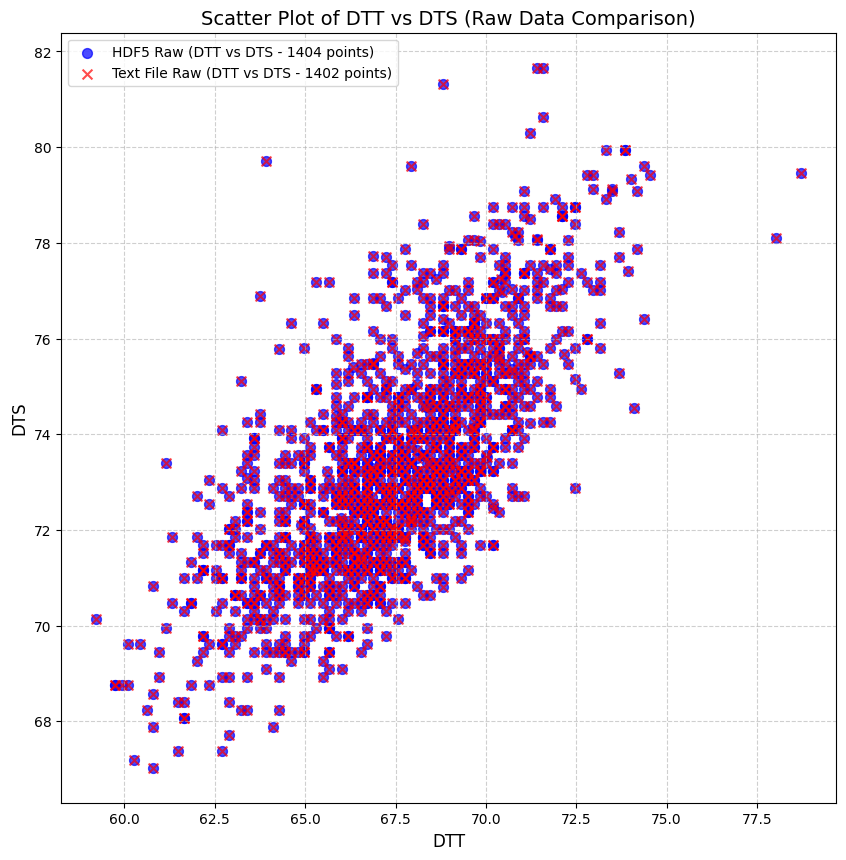

Plot displayed.


In [ ]:
# In the second code cell (id: 647de591)

# ... existing imports ...
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging # Added for consistency, though not strictly needed for plotting

# Setup basic logging (optional, mimics datamodule)
logger = logging.getLogger("TestPhenotypeNotebook")
logging.basicConfig(level=logging.INFO)

# Define the phenotypes to plot
pheno1 = 'DTT'
pheno2 = 'DTS'
phenotypes_to_load = [pheno1, pheno2] # List of phenotypes needed

# --- Define Parameters and File Paths ---
h5_file_path = '/media/marxin/softs/workspace/Whisper_of_DNA_pl/data/example-data/wheat599/SNP_origin/wheatY.csv'
txt_file_path = '/media/marxin/softs/workspace/Whisper_of_DNA_pl/data/maize1404_genotype/Agronomic_23Traits.txt'


# --- Load Data Source 1: Processed data (from HDF5, unnormalized) ---
# Adapted logic from datamodule.py _load_data and _process_phenotypes
logger.info(f"Loading data from HDF5 file: {h5_file_path}")
phenotypes_h5_selected = np.empty((0, 2)) # Initialize empty array

try:
    with h5py.File(h5_file_path, 'r') as f:
        # Check for 'phenotypes' key first, fallback to 'phenotype'
        phenotype_key = 'phenotypes' if 'phenotypes' in f else 'phenotype'
        if phenotype_key not in f:
             raise KeyError(f"Could not find 'phenotypes' or 'phenotype' dataset in HDF5 file.")
        all_phenotypes_h5 = f[phenotype_key][:] # Load all phenotype data (samples x phenotypes)

        if 'phenotype_names' not in f:
            raise KeyError("Could not find 'phenotype_names' dataset in HDF5 file.")
        # Load and decode phenotype names (similar to datamodule)
        all_phenotype_names_h5 = []
        for name_bytes in f['phenotype_names'][:]:
            if isinstance(name_bytes, bytes):
                name = name_bytes.decode('utf-8')
            elif isinstance(name_bytes, np.ndarray):
                name = name_bytes.item().decode('utf-8') if hasattr(name_bytes.item(), 'decode') else str(name_bytes.item())
            else:
                name = str(name_bytes)
            all_phenotype_names_h5.append(name)

        logger.info(f"Successfully loaded {all_phenotypes_h5.shape[0]} samples and {len(all_phenotype_names_h5)} phenotypes from HDF5.")
        logger.info(f"Available phenotypes in HDF5: {all_phenotype_names_h5}")

    # Find indices for the selected phenotypes (similar to _process_phenotypes)
    phenotype_indices_h5 = []
    phenotype_names_found = []
    unmatched_phenotypes = []

    for name_to_find in phenotypes_to_load:
        found = False
        try:
            # Try exact match first
            idx = all_phenotype_names_h5.index(name_to_find)
            phenotype_indices_h5.append(idx)
            phenotype_names_found.append(all_phenotype_names_h5[idx])
            logger.info(f"Found '{name_to_find}' at index {idx} in HDF5.")
            found = True
        except ValueError:
            # Optional: Try case-insensitive match (like in datamodule)
            for i, dataset_name in enumerate(all_phenotype_names_h5):
                 if isinstance(name_to_find, str) and isinstance(dataset_name, str) and name_to_find.lower() == dataset_name.lower():
                    phenotype_indices_h5.append(i)
                    phenotype_names_found.append(dataset_name)
                    logger.info(f"Found '{name_to_find}' (case-insensitive as '{dataset_name}') at index {i} in HDF5.")
                    found = True
                    break
        if not found:
            unmatched_phenotypes.append(name_to_find)
            logger.warning(f"Phenotype '{name_to_find}' not found in HDF5 file.")

    if len(phenotype_indices_h5) == len(phenotypes_to_load):
        # Extract the corresponding columns using the found indices
        # Ensure the order matches pheno1, pheno2 definition
        idx1_h5 = phenotype_indices_h5[phenotypes_to_load.index(pheno1)]
        idx2_h5 = phenotype_indices_h5[phenotypes_to_load.index(pheno2)]

        pheno1_data_h5 = all_phenotypes_h5[:, idx1_h5]
        pheno2_data_h5 = all_phenotypes_h5[:, idx2_h5]
        phenotypes_h5_selected = np.vstack((pheno1_data_h5, pheno2_data_h5)).T # Combine into N x 2 array
        logger.info(f"Extracted data for '{pheno1}' and '{pheno2}' from HDF5. Shape: {phenotypes_h5_selected.shape}")

        # Optional: Check for NaNs in HDF5 data if necessary (datamodule does this later)
        # initial_rows_h5 = phenotypes_h5_selected.shape[0]
        # phenotypes_h5_selected = phenotypes_h5_selected[~np.isnan(phenotypes_h5_selected).any(axis=1)]
        # rows_after_nan_h5 = phenotypes_h5_selected.shape[0]
        # if initial_rows_h5 != rows_after_nan_h5:
        #     logger.info(f"Removed {initial_rows_h5 - rows_after_nan_h5} rows containing NaN from HDF5 data. Final shape: {phenotypes_h5_selected.shape}")

    else:
        logger.error(f"Could not find all required phenotypes in HDF5: Needed {phenotypes_to_load}, Found indices for {phenotype_names_found}")
        # phenotypes_h5_selected remains empty

except FileNotFoundError:
    logger.error(f"Error: HDF5 file not found at {h5_file_path}")
except KeyError as e:
    logger.error(f"Error: Dataset missing in HDF5 file: {e}")
except Exception as e:
    logger.error(f"An error occurred while reading the HDF5 file: {e}", exc_info=True)


# --- Load Data Source 2: Raw data (from text file) ---
# Keep the existing text file loading logic
print(f"\nLoading data from text file: {txt_file_path}")
try:
    # Read the text file, assuming tab-separated and header row
    df_txt = pd.read_csv(txt_file_path, sep='\t', index_col=0) # Assuming first column is index
    print(f"Successfully loaded text file. Shape: {df_txt.shape}")

    # Check if the selected phenotypes exist in the columns
    if pheno1 in df_txt.columns and pheno2 in df_txt.columns:
        print(f"Found '{pheno1}' and '{pheno2}' columns in the text file.")
        # Extract the corresponding columns
        pheno1_data_txt = df_txt[pheno1].values
        pheno2_data_txt = df_txt[pheno2].values
        phenotypes_txt_selected = np.vstack((pheno1_data_txt, pheno2_data_txt)).T # Combine into N x 2 array
        print(f"Extracted data for '{pheno1}' and '{pheno2}' from text file. Initial shape: {phenotypes_txt_selected.shape}")

        # Handle potential non-numeric data or NaNs introduced during read
        initial_rows = phenotypes_txt_selected.shape[0]
        # Ensure data is numeric before checking for NaN
        phenotypes_txt_selected = phenotypes_txt_selected.astype(float)
        phenotypes_txt_selected = phenotypes_txt_selected[~np.isnan(phenotypes_txt_selected).any(axis=1)]
        rows_after_nan_removal = phenotypes_txt_selected.shape[0]
        if initial_rows != rows_after_nan_removal:
            print(f"Removed {initial_rows - rows_after_nan_removal} rows containing NaN values. Final shape: {phenotypes_txt_selected.shape}")
        else:
            print("No NaN values found in selected columns.")


    else:
        print(f"Error: Phenotypes '{pheno1}' or '{pheno2}' not found in {txt_file_path}")
        print(f"Available columns: {df_txt.columns.tolist()}")
        phenotypes_txt_selected = np.empty((0, 2)) # Empty array if columns not found

except FileNotFoundError:
    print(f"Error: Text file not found at {txt_file_path}")
    phenotypes_txt_selected = np.empty((0, 2)) # Empty array if file not found
except Exception as e:
    print(f"An error occurred while reading the text file: {e}")
    phenotypes_txt_selected = np.empty((0, 2)) # Empty array on other errors


# --- Plotting ---
# The plotting code remains the same, using phenotypes_h5_selected and phenotypes_txt_selected
print("\nGenerating scatter plot...")
plt.figure(figsize=(10, 10)) # Increased figure size for better visibility

# Plot data from HDF5
if phenotypes_h5_selected.shape[0] > 0:
    plt.scatter(phenotypes_h5_selected[:, 0], phenotypes_h5_selected[:, 1], alpha=0.7, label=f'HDF5 Raw ({pheno1} vs {pheno2} - {phenotypes_h5_selected.shape[0]} points)', color='blue', s=50) # Updated label
    print(f"Plotting {phenotypes_h5_selected.shape[0]} points from HDF5.")
else:
    print("No data from HDF5 to plot.")

# Plot data from text file
if phenotypes_txt_selected.shape[0] > 0:
    plt.scatter(phenotypes_txt_selected[:, 0], phenotypes_txt_selected[:, 1], alpha=0.7, label=f'Text File Raw ({pheno1} vs {pheno2} - {phenotypes_txt_selected.shape[0]} points)', color='red', marker='x', s=50) # Updated label
    print(f"Plotting {phenotypes_txt_selected.shape[0]} points from text file.")
else:
    print("No data from text file to plot.")

# Add labels and title
plt.xlabel(pheno1, fontsize=12)
plt.ylabel(pheno2, fontsize=12)
plt.title(f'Scatter Plot of {pheno1} vs {pheno2} (Raw Data Comparison)', fontsize=14) # Updated title
plt.grid(True, linestyle='--', alpha=0.6)

# Add legend only if there's data to show
if phenotypes_h5_selected.shape[0] > 0 or phenotypes_txt_selected.shape[0] > 0:
    plt.legend(fontsize=10)
else:
    plt.text(0.5, 0.5, 'No data available to plot', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12, color='gray')


plt.show()
print("Plot displayed.")

# ... rest of the notebook ...

INFO:TestPhenotypeNormalizationSplit:Loading data from HDF5 file: /media/marxin/softs/workspace/Whisper_of_DNA_pl/output/maize1404_test_memory/maize1404_preprocessed_newtry.h5
INFO:TestPhenotypeNormalizationSplit:Loaded 1404 samples and 23 phenotypes from HDF5.
INFO:TestPhenotypeNormalizationSplit:Found 'KNPE' at index 12 in HDF5.
INFO:TestPhenotypeNormalizationSplit:Found 'KWPE' at index 14 in HDF5.
INFO:TestPhenotypeNormalizationSplit:Extracted data for 'KNPE' and 'KWPE'. Initial shape: (1404, 2)
INFO:TestPhenotypeNormalizationSplit:Removed 17 rows containing NaN. Final shape: (1387, 2)
INFO:TestPhenotypeNormalizationSplit:Calculated normalization stats for KNPE, KWPE:
INFO:TestPhenotypeNormalizationSplit:  Mean: [305.48121099  71.83403239]
INFO:TestPhenotypeNormalizationSplit:  Std Dev: [54.15775803 10.87217631]
INFO:TestPhenotypeNormalizationSplit:Phenotype data normalized.
INFO:TestPhenotypeNormalizationSplit:Data split (local indices): Train=971, Val=208, Test=208



Generating scatter plot for normalized data with splits...


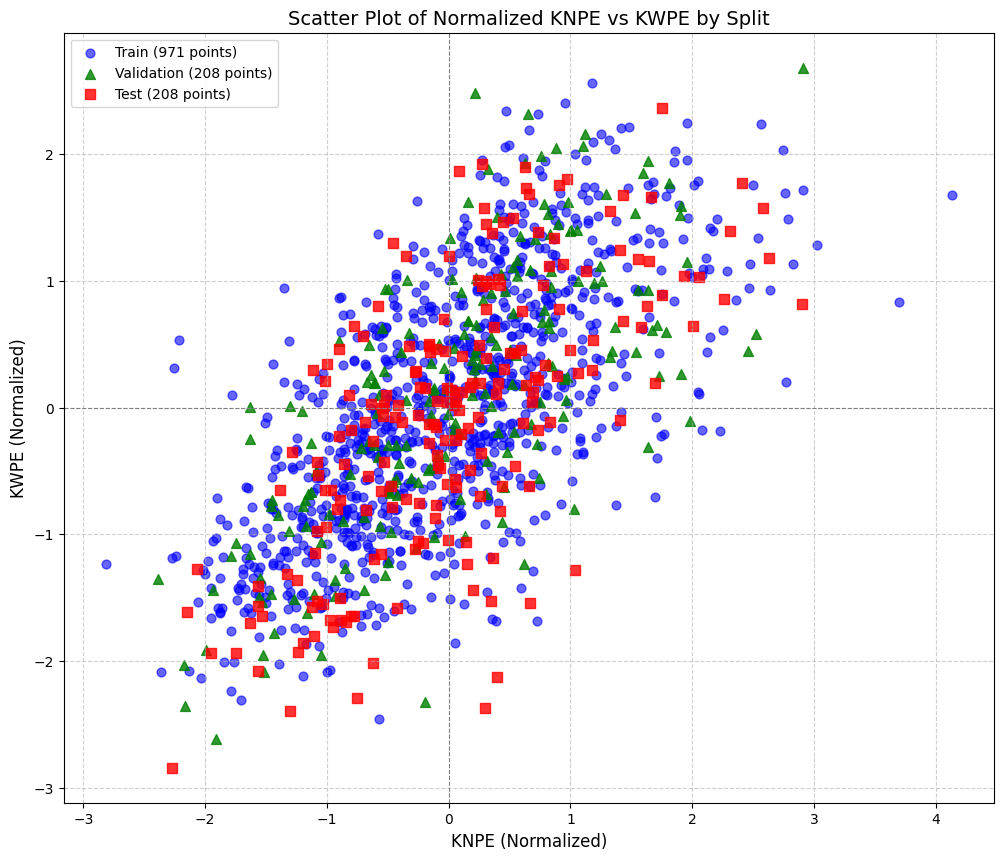

INFO:TestPhenotypeNormalizationSplit:Stored unnormalized, filtered 'KNPE' data for distribution plot.


Normalized data plot displayed.


In [3]:
# In a new code cell
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
import random
import seaborn as sns # For distribution plot
from scipy import stats # For distribution stats

# Setup basic logging (optional, mimics datamodule)
logger = logging.getLogger("TestPhenotypeNormalizationSplit")
logging.basicConfig(level=logging.INFO)

# --- Parameters (reuse from previous cell or define) ---
pheno1 = 'KNPE'
pheno2 = 'KWPE'
phenotypes_to_load = [pheno1, pheno2]
h5_file_path = '/media/marxin/softs/workspace/Whisper_of_DNA_pl/output/maize1404_test_memory/maize1404_preprocessed_newtry.h5'
seed = 42 # For reproducible splitting
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# --- Load HDF5 Data (similar to previous cell, ensure all data is loaded initially) ---
logger.info(f"Loading data from HDF5 file: {h5_file_path}")
phenotypes_h5_all = np.empty((0, 2)) # Initialize empty array for selected phenotypes
all_phenotype_names_h5 = []
original_sample_count = 0

try:
    with h5py.File(h5_file_path, 'r') as f:
        phenotype_key = 'phenotypes' if 'phenotypes' in f else 'phenotype'
        if phenotype_key not in f:
             raise KeyError(f"Could not find 'phenotypes' or 'phenotype' dataset in HDF5 file.")
        all_phenotypes_h5_raw = f[phenotype_key][:]
        original_sample_count = all_phenotypes_h5_raw.shape[0]

        if 'phenotype_names' not in f:
            raise KeyError("Could not find 'phenotype_names' dataset in HDF5 file.")
        for name_bytes in f['phenotype_names'][:]:
            if isinstance(name_bytes, bytes): name = name_bytes.decode('utf-8')
            elif isinstance(name_bytes, np.ndarray): name = name_bytes.item().decode('utf-8') if hasattr(name_bytes.item(), 'decode') else str(name_bytes.item())
            else: name = str(name_bytes)
            all_phenotype_names_h5.append(name)

        logger.info(f"Loaded {original_sample_count} samples and {len(all_phenotype_names_h5)} phenotypes from HDF5.")

    # Find indices for the selected phenotypes
    phenotype_indices_h5 = []
    for name_to_find in phenotypes_to_load:
        try:
            idx = all_phenotype_names_h5.index(name_to_find)
            phenotype_indices_h5.append(idx)
            logger.info(f"Found '{name_to_find}' at index {idx} in HDF5.")
        except ValueError:
             logger.error(f"Phenotype '{name_to_find}' not found in HDF5 file. Aborting.")
             raise # Re-raise the error to stop execution

    if len(phenotype_indices_h5) == len(phenotypes_to_load):
        idx1_h5 = phenotype_indices_h5[phenotypes_to_load.index(pheno1)]
        idx2_h5 = phenotype_indices_h5[phenotypes_to_load.index(pheno2)]
        phenotypes_h5_all = all_phenotypes_h5_raw[:, [idx1_h5, idx2_h5]] # Extract N x 2 array
        logger.info(f"Extracted data for '{pheno1}' and '{pheno2}'. Initial shape: {phenotypes_h5_all.shape}")

        # --- Explicit NA Removal (Mimics datamodule._process_phenotypes) ---
        initial_rows_h5 = phenotypes_h5_all.shape[0]
        nan_mask = np.isnan(phenotypes_h5_all).any(axis=1)
        valid_sample_indices_original = np.where(~nan_mask)[0] # Indices relative to original 0..N-1
        phenotypes_h5_filtered = phenotypes_h5_all[~nan_mask]
        rows_after_nan_h5 = phenotypes_h5_filtered.shape[0]
        if initial_rows_h5 != rows_after_nan_h5:
            logger.info(f"Removed {initial_rows_h5 - rows_after_nan_h5} rows containing NaN. Final shape: {phenotypes_h5_filtered.shape}")
        else:
            logger.info("No NaN values found in selected HDF5 phenotypes.")

        if rows_after_nan_h5 == 0:
             raise ValueError("No valid samples remaining after NaN removal.")

        # --- Normalize Phenotypes (Mimics datamodule._prepare_features) ---
        phenotype_mean = np.mean(phenotypes_h5_filtered, axis=0)
        phenotype_std = np.std(phenotypes_h5_filtered, axis=0)
        phenotype_std = np.where(phenotype_std > 1e-8, phenotype_std, 1.0) # Avoid division by zero
        logger.info(f"Calculated normalization stats for {pheno1}, {pheno2}:")
        logger.info(f"  Mean: {phenotype_mean}")
        logger.info(f"  Std Dev: {phenotype_std}")

        phenotypes_h5_normalized = (phenotypes_h5_filtered - phenotype_mean) / phenotype_std
        logger.info("Phenotype data normalized.")

        # --- Split Data (Mimics datamodule._prepare_splits) ---
        n_samples_after_na = rows_after_nan_h5
        local_indices = np.arange(n_samples_after_na) # Indices relative to the filtered data (0 to n_samples_after_na-1)
        np.random.seed(seed)
        np.random.shuffle(local_indices)

        # Ensure ratios sum to 1 (or close enough)
        if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
             logger.warning("Split ratios do not sum to 1. Normalizing.")
             total = train_ratio + val_ratio + test_ratio
             train_ratio /= total
             val_ratio /= total
             test_ratio = 1.0 - train_ratio - val_ratio

        test_size = int(np.floor(n_samples_after_na * test_ratio))
        val_size = int(np.floor(n_samples_after_na * val_ratio))
        train_size = n_samples_after_na - test_size - val_size

        # Basic validation for split sizes
        if train_size <= 0 or val_size <= 0 or test_size <= 0:
             logger.warning(f"Calculated split sizes are not all positive (train={train_size}, val={val_size}, test={test_size}). Adjusting.")
             # Simple adjustment: ensure at least 1 sample if ratio > 0 and possible
             test_size = max(1, test_size) if test_ratio > 0 and n_samples_after_na > 2 else max(0, test_size)
             val_size = max(1, val_size) if val_ratio > 0 and n_samples_after_na > test_size + 1 else max(0, val_size)
             train_size = n_samples_after_na - test_size - val_size
             if train_size <= 0:
                 raise ValueError("Cannot create valid train/val/test splits with current ratios and data size.")

        train_indices_local = local_indices[:train_size]
        val_indices_local = local_indices[train_size : train_size + val_size]
        test_indices_local = local_indices[train_size + val_size :]

        logger.info(f"Data split (local indices): Train={len(train_indices_local)}, Val={len(val_indices_local)}, Test={len(test_indices_local)}")

        # --- Plot Normalized Data with Splits ---
        print("\nGenerating scatter plot for normalized data with splits...")
        plt.figure(figsize=(12, 10))

        # Plot Train data
        if len(train_indices_local) > 0:
            plt.scatter(phenotypes_h5_normalized[train_indices_local, 0], phenotypes_h5_normalized[train_indices_local, 1],
                        alpha=0.6, label=f'Train ({len(train_indices_local)} points)', color='blue', marker='o', s=40)
        # Plot Validation data
        if len(val_indices_local) > 0:
            plt.scatter(phenotypes_h5_normalized[val_indices_local, 0], phenotypes_h5_normalized[val_indices_local, 1],
                        alpha=0.8, label=f'Validation ({len(val_indices_local)} points)', color='green', marker='^', s=50)
        # Plot Test data
        if len(test_indices_local) > 0:
            plt.scatter(phenotypes_h5_normalized[test_indices_local, 0], phenotypes_h5_normalized[test_indices_local, 1],
                        alpha=0.8, label=f'Test ({len(test_indices_local)} points)', color='red', marker='s', s=50)

        plt.xlabel(f"{pheno1} (Normalized)", fontsize=12)
        plt.ylabel(f"{pheno2} (Normalized)", fontsize=12)
        plt.title(f'Scatter Plot of Normalized {pheno1} vs {pheno2} by Split', fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(fontsize=10)
        plt.axhline(0, color='grey', lw=0.8, linestyle='--') # Add lines at 0 for reference
        plt.axvline(0, color='grey', lw=0.8, linestyle='--')
        plt.show()
        print("Normalized data plot displayed.")

    else:
        logger.error(f"Could not find all required phenotypes in HDF5: Needed {phenotypes_to_load}")

except FileNotFoundError:
    logger.error(f"Error: HDF5 file not found at {h5_file_path}")
except KeyError as e:
    logger.error(f"Error: Dataset missing in HDF5 file: {e}")
except ValueError as e:
     logger.error(f"Error during processing: {e}")
except Exception as e:
    logger.error(f"An unexpected error occurred: {e}", exc_info=True)

# Store the filtered, unnormalized pheno1 data for the next cell
# Ensure 'phenotypes_h5_filtered' exists and has data before accessing
pheno1_data_unnormalized_filtered = None
if 'phenotypes_h5_filtered' in locals() and phenotypes_h5_filtered.shape[0] > 0:
     pheno1_data_unnormalized_filtered = phenotypes_h5_filtered[:, 0]
     logger.info(f"Stored unnormalized, filtered '{pheno1}' data for distribution plot.")
else:
     logger.warning(f"Could not obtain filtered, unnormalized '{pheno1}' data. Distribution plot might fail.")



Generating distribution plot for 'DTA' (Unnormalized, Filtered)...


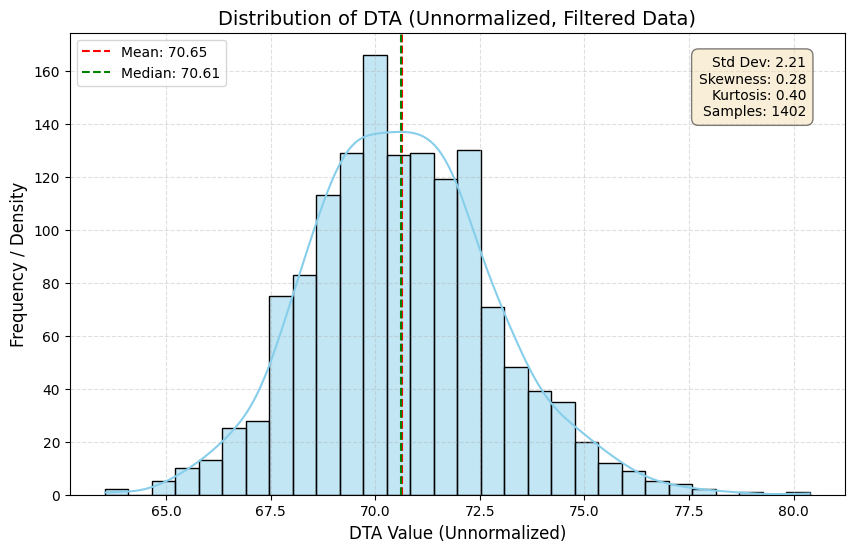

Distribution plot for 'DTA' displayed.


In [13]:
# In a new code cell following the previous one

# --- Plot Distribution of Phenotype 1 (Unnormalized, Filtered) ---

if pheno1_data_unnormalized_filtered is not None:
    print(f"\nGenerating distribution plot for '{pheno1}' (Unnormalized, Filtered)...")

    plt.figure(figsize=(10, 6))

    # Plot Histogram and KDE using seaborn
    sns.histplot(pheno1_data_unnormalized_filtered, kde=True, bins=30, color='skyblue')

    # Calculate statistics
    mean_val = np.mean(pheno1_data_unnormalized_filtered)
    median_val = np.median(pheno1_data_unnormalized_filtered)
    std_val = np.std(pheno1_data_unnormalized_filtered)
    skew_val = stats.skew(pheno1_data_unnormalized_filtered)
    kurt_val = stats.kurtosis(pheno1_data_unnormalized_filtered) # Fisher's kurtosis (normal=0)

    # Add vertical lines for mean and median
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='dashed', linewidth=1.5, label=f'Median: {median_val:.2f}')

    # Add text box for statistics
    stats_text = (f"Std Dev: {std_val:.2f}\n"
                  f"Skewness: {skew_val:.2f}\n"
                  f"Kurtosis: {kurt_val:.2f}\n"
                  f"Samples: {len(pheno1_data_unnormalized_filtered)}")
    # Place text box in upper right corner
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

    plt.xlabel(f"{pheno1} Value (Unnormalized)", fontsize=12)
    plt.ylabel("Frequency / Density", fontsize=12)
    plt.title(f"Distribution of {pheno1} (Unnormalized, Filtered Data)", fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()
    print(f"Distribution plot for '{pheno1}' displayed.")

else:
    print(f"\nSkipping distribution plot for '{pheno1}' as data is not available.")
